In [ ]:
# Monday 21st September 2026
# Removed WBTC-USD, WETH-USD and BTCB-USD since they are duplicates of BTC and ETH
# Removed PAXG and XAUt since they are gold-backed currencies that behave differently from the rest of the crypto universe
# Removed coingecko scraping

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import requests

In [73]:
# ticker_universe = ["BTC-USD", "ETH-USD", "LINK-USD", "SOL-USD", "AVAX-USD", "XRP-USD", "BNB-USD", "LTC-USD", "ADA-USD", "DOT-USD", "DOGE-USD", "MATIC-USD"]

# I decided to create a clean universe of 20-30 coins picked myself from coinmarketcap.com. The coins are meant to be reasonably liquid, non-stablecoin cryptos that have at least 6 years of history.

# New ticker universe created by looking at coinmarketcap.com and picking non-stable coins that have a sufficiently large market cap and daily volume (500M USD AND 50M USD)
# they must also be at least 6 years old (started before September 2020)
# This means that some coins may appear during the backtesting time period but I don't think it will be that problematic
ticker_universe = ["BTC-USD", "ETH-USD", "BNB-USD", "XRP-USD", "SOL-USD", "ZEC-USD", "DOGE-USD", "ADA-USD", "XLM-USD", "BCH-USD", "NEAR-USD", "AVAX-USD", "HBAR-USD", "SHIB-USD", "KCS-USD"]

In [74]:
# Downloads the prices from yfinance
daily_prices = yf.download(tickers=ticker_universe, period="max", interval="1d")

[*********************100%***********************]  15 of 15 completed


In [75]:
# Calculates daily returns and daily volumes from daily prices
daily_returns = (daily_prices["Close"] / daily_prices["Close"].shift() - 1).iloc[1:].loc["2020-01-01":]
daily_volumes = daily_prices["Volume"].loc["2020-01-01":]

In [76]:
def zScore(x, window=120):
    return (x - x.rolling(window).mean()) / x.rolling(window).std()

In [77]:
def sharpeRatio(x):
    return x.mean() / x.std() * np.sqrt(252)

In [214]:
# Calculates weights for momentum strategy
# rolling periods for signal calculations can be varied

# I adjusted the rolling parameters for this function to slow down the signal to reduce transaction costs
# After playing around with the parameters for a little bit, I found these values to work best for the time being
def momentumWeights(returns, returns_rolling=14, volatility_rolling=45, lag_period=2):
    signal = returns.shift().rolling(returns_rolling).mean() / returns.shift().rolling(volatility_rolling).std()
    ranked = signal.rank(axis=1)
    demeaned = ranked.sub(ranked.mean(axis=1), axis=0)
    weights = demeaned.div(demeaned.abs().sum(axis=1), axis=0)
    lagged_weights = weights.iloc[::lag_period].reindex(weights.index, method="ffill")
    return lagged_weights

In [215]:
# Creating the returns for the momentum strategy
momentum_strategy = (momentumWeights(daily_returns) * daily_returns).sum(axis=1)

In [216]:
# Calculating turnover and hence net returns of (momentum) strategy.
# the constrained backtest has a sharpe of 0.26.
def calculateTurnOver(weights):
    return (weights - weights.shift()).abs().sum(axis=1)

def calculateNetReturns(daily_returns, weights):
    gross_returns = (weights * daily_returns).sum(axis=1)
    turnover = calculateTurnOver(weights)
    net_returns = gross_returns.subtract(turnover * 0.002, fill_value=0)
    return net_returns

net_momentum_returns = calculateNetReturns(daily_returns, momentumWeights(daily_returns))
sharpeRatio(net_momentum_returns)

np.float64(0.9426872114226277)

<Axes: title={'center': 'Sharpe Ratio of Net Momentum Strategy Each Quarter'}, xlabel='Date', ylabel='Sharpe Ratio (Constrained)'>

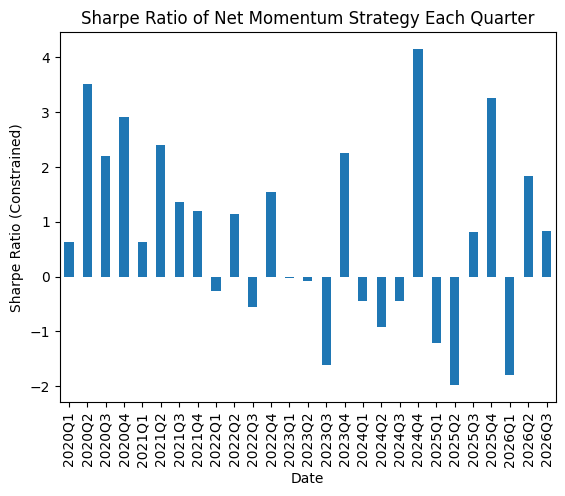

In [247]:
net_momentum_returns.resample("QE").apply(sharpeRatio).to_period("Q").plot(kind="bar", title="Sharpe Ratio of Net Momentum Strategy Each Quarter", ylabel="Sharpe Ratio (Constrained)")

In [218]:
# Calculates important summary metrics for the strategy
def strategySummary(strategy, rolling_window=14, market_threshold=0.08):
    market_trend = daily_returns['BTC-USD'].shift().rolling(window=rolling_window).sum()

    bullish_trend = market_trend > market_threshold
    bearish_trend = market_trend < -market_threshold
    choppy_trend = (market_trend > -market_threshold) & (market_trend < market_threshold)

    print(f"Overall Sharpe Ratio: {sharpeRatio(strategy):.3f}")
    print("")
    print(f"Choppy market Sharpe: {sharpeRatio(strategy[choppy_trend]):.3f}")
    print(f"Bullish market Sharpe: {sharpeRatio(strategy[bullish_trend]):.3f}")
    print(f"Bearish market Sharpe: {sharpeRatio(strategy[bearish_trend]):.3f}")
    print()
    print(f"Hit Rate: {(strategy > 0).mean():.3f}")
    print(f"Avg Win: {strategy[strategy > 0].mean():.3f}")
    print(f"Avg Loss: {strategy[strategy < 0].mean():.3f}")
    print(f"Win/Loss Ratio: {-strategy[strategy > 0].mean() / strategy[strategy < 0].mean():.2f}")
    print("")
    print(f"Percentage of choppy days: {choppy_trend.mean():.2f}")

In [219]:
# the constrained backtest has a sharpe ratio of 0.26.
strategySummary(net_momentum_returns)

Overall Sharpe Ratio: 0.943

Choppy market Sharpe: 1.108
Bullish market Sharpe: 1.657
Bearish market Sharpe: -1.055

Hit Rate: 0.482
Avg Win: 0.011
Avg Loss: -0.009
Win/Loss Ratio: 1.25

Percentage of choppy days: 0.60


In [220]:
# The unconstrained backtest has a sharpe ratio of 0.83.
strategySummary(momentum_strategy)

Overall Sharpe Ratio: 1.458

Choppy market Sharpe: 1.738
Bullish market Sharpe: 2.024
Bearish market Sharpe: -0.519

Hit Rate: 0.509
Avg Win: 0.011
Avg Loss: -0.009
Win/Loss Ratio: 1.25

Percentage of choppy days: 0.60


SHIB-USD    0.015929
DOGE-USD    0.019952
BTC-USD     0.020318
BCH-USD     0.021257
ETH-USD     0.021902
ZEC-USD     0.023673
NEAR-USD    0.023755
BNB-USD     0.025313
ADA-USD     0.025925
SOL-USD     0.033446
HBAR-USD    0.037145
XLM-USD     0.037479
XRP-USD     0.039266
KCS-USD     0.052361
AVAX-USD    0.054078
dtype: float64

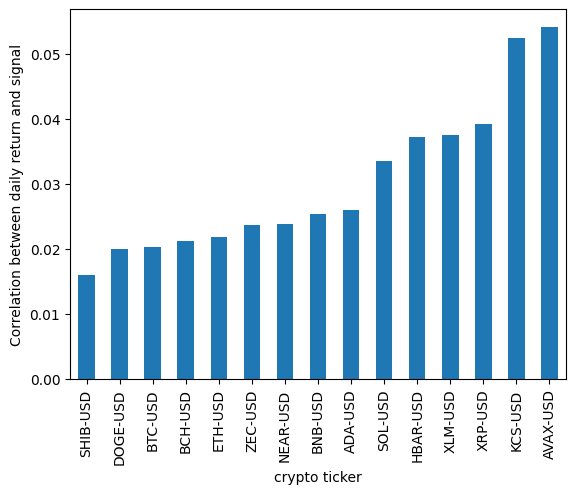

In [221]:
pd.Series({ticker: daily_returns[ticker].corr(daily_returns[ticker].shift().rolling(7).mean() / daily_returns[ticker].shift().rolling(7).std()) for ticker in ticker_universe}).sort_values().plot(kind="bar", ylabel="Correlation between daily return and signal", xlabel="crypto ticker")
pd.Series({ticker: daily_returns[ticker].corr(daily_returns[ticker].shift().rolling(7).mean() / daily_returns[ticker].shift().rolling(7).std()) for ticker in ticker_universe}).sort_values()

The bar plot shows the correlation between an asset's daily returns and signal. This is meant to be a measure of how strong momentum is for that asset. I will try removing the assets with the weakest momentums (XMR, LTC, LINK, TRX, ALGO and DASH) since the correlation is to low (below 0.01).

In [222]:
pd.Series({ticker: daily_returns[ticker].corr(daily_returns[ticker].shift().rolling(7).mean() / daily_returns[ticker].shift().rolling(7).std()) for ticker in ticker_universe}).sort_values().index.tolist()

['SHIB-USD',
 'DOGE-USD',
 'BTC-USD',
 'BCH-USD',
 'ETH-USD',
 'ZEC-USD',
 'NEAR-USD',
 'BNB-USD',
 'ADA-USD',
 'SOL-USD',
 'HBAR-USD',
 'XLM-USD',
 'XRP-USD',
 'KCS-USD',
 'AVAX-USD']